#**APPLE** **STORE** **DATA** **ANALYTICS** **WITH** **MY** **SQL** **AND** **PYTHON**

This project explores a 2 datasets on apps on Apple Store to draw insights to
assist an app developer who needs data driven insights to decide on what type of app to build.

#**Setting** **up**

### Importing relevant libraries

In [ ]:
%load_ext sql

In [ ]:
import sqlite3
import pandas as pd
import csv

### Loading Data to SQL from a Pandas Dataframe

In [ ]:
# Load the AppleStore.csv dataset into a pandas DataFrame
df_store=pd.read_csv('/content/AppleStore.csv', sep=',', low_memory=False)
# Print the no. of rows and columns in the DataFrame
print(f'The dataset has {df_store.shape[0]} rows and {df_store.shape[1]} columns')

The dataset has 7197 rows and 17 columns


In [ ]:
# Display the first 5 rows
df_store.head()

,Unnamed: 0,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices_num,ipadSc_urls_num,lang_num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


In [ ]:
# Load the dataset into a pandas
df_desc=pd.read_csv('/content/appleStore_description.csv', sep=',', low_memory=False)
# Print the no. of rows and columns in the DataFrame
print(f'The dataset has {df_desc.shape[0]} rows and {df_desc.shape[1]} columns')

The dataset has 7197 rows and 4 columns


In [ ]:
# Display the first 5 rows
df_desc.head()

,id,track_name,size_bytes,app_desc
0,281656475,PAC-MAN Premium,100788224,"SAVE 20%, now only $3.99 for a limited time!\n..."
1,281796108,Evernote - stay organized,158578688,Let Evernote change the way you organize your ...
2,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,Download the most popular free weather app pow...
3,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,The eBay app is the best way to find anything ...
4,282935706,Bible,92774400,On more than 250 million devices around the wo...


### Creating a database file

In [ ]:
# Create a SQLite DB file and connect
conn = sqlite3.connect("AppStore.db")

In [ ]:
# Write the dataframes to the SQLite database
df_store.to_sql('AppleStore', conn, index=False, if_exists='replace')
df_desc.to_sql('appleStore_desc', conn, index=False, if_exists='replace')

7197

In [ ]:
# Load connect to the SQLite database
%sql sqlite:///AppStore.db

# **Overview**

In [ ]:
!pip install --upgrade prettytable==3.10.0

  Attempting uninstall: prettytable
    Found existing installation: prettytable 3.16.0
    Uninstalling prettytable-3.16.0:
      Successfully uninstalled prettytable-3.16.0


In [ ]:
## No. of unique apps
%%sql
SELECT DISTINCT
    COUNT(id) AS UniqueAppIds
FROM
  appleStore_desc;

 * sqlite:///AppStore.db
Done.


UniqueAppIds
7197


#### The value is same (7197) indicating no missing app IDs in the two tables

### Checking for missing values


In [ ]:
# Check for missing values in key columns
%%sql
SELECT DISTINCT
    COUNT(*) AS MissingValues
FROM
  Applestore
WHERE
  track_name IS NULL
   OR
    user_rating IS NULL
   OR
    prime_genre IS NULL;

 * sqlite:///AppStore.db
Done.


MissingValues
0


In [ ]:
# Check for missing values in app description
%%sql
SELECT DISTINCT
    COUNT(*) AS MissingValues
FROM
  appleStore_desc
WHERE
  app_desc IS NULL;

 * sqlite:///AppStore.db
Done.


MissingValues
0


### Number of apps per genre

In [ ]:
# No. of apps per genre, ordered by the no. of apps
%%sql
SELECT DISTINCT
    prime_genre, COUNT(*) AS NumApps
FROM
  Applestore
GROUP BY
  prime_genre
ORDER BY
  NumApps DESC;

 * sqlite:///AppStore.db
Done.


prime_genre,NumApps
Games,3862
Entertainment,535
Education,453
Photo & Video,349
Utilities,248
Health & Fitness,180
Productivity,178
Social Networking,167
Lifestyle,144
Music,138


### Overview of user ratings

In [ ]:
# Overview of user ratings (minimum, average, and maximum)
%%sql
SELECT
    MIN(user_rating) AS min_user_rating,
    round(AVG(user_rating),1) AS avg_user_rating,
    MAX(user_rating) AS max_user_rating
FROM
  Applestore;

 * sqlite:///AppStore.db
Done.


min_user_rating,avg_user_rating,max_user_rating
0.0,3.5,5.0


# **Data** **Analysis**

In [ ]:
# Average user ratings for paid vs free apps
%%sql
SELECT CASE
        WHEN price > 0 THEN 'paid'
        ELSE 'free'
    END AS app_type,
    ROUND(AVG(user_rating), 1) AS avg_rating
FROM AppleStore
GROUP BY app_type;

 * sqlite:///AppStore.db
Done.


app_type,avg_rating
free,3.4
paid,3.7


Paid apps have a slightly higher average rating (3.7) compared to free apps (3.4).

In [ ]:
# Average user ratings based on the no. of supported languages
%%sql
SELECT CASE
  WHEN
    lang_num < 10 THEN '<10 languages'
  WHEN
    lang_num BETWEEN 10 AND 30 THEN '10-30 languages'
  ELSE
    '>30 languages'
  END AS
    language_bracket,
  round(avg(user_rating),1) AS avg_rating
FROM
  AppleStore
GROUP BY
  language_bracket
ORDER BY
  avg_rating DESC;

 * sqlite:///AppStore.db
Done.


language_bracket,avg_rating
10-30 languages,4.1
>30 languages,3.8
<10 languages,3.4


Apps supporting 10-30 languages have the highest average rating (4.1), followed by >30 languages (3.8), and <10 languages (3.4).


In [ ]:
# Top 10 genres with the lowest average user ratings
%%sql
SELECT prime_genre,
  round(AVG(user_rating),1) AS avg_rating
FROM
  AppleStore
GROUP BY
  prime_genre
ORDER BY
  avg_rating ASC
LIMIT
  10;

 * sqlite:///AppStore.db
Done.


prime_genre,avg_rating
Catalogs,2.1
Finance,2.4
Book,2.5
Navigation,2.7
Lifestyle,2.8
News,3.0
Social Networking,3.0
Sports,3.0
Entertainment,3.2
Food & Drink,3.2


"Catalogs" (2.1), "Finance" (2.4), and "Book" (2.5) genres have the lowest average ratings.


In [ ]:
# Average user rating based on app description length
%%sql
SELECT CASE
        WHEN length(b.app_desc) < 500 THEN 'Short'
        WHEN length(b.app_desc) BETWEEN 500 AND 1000 THEN 'Medium'
        ELSE 'Long'
    END AS description_length_bucket,
    ROUND(AVG(user_rating),1)
    AS avg_rating
FROM
  AppleStore AS a
JOIN
  appleStore_desc AS b
ON
  a.id = b.id
GROUP BY
  description_length_bucket
ORDER BY
  avg_rating DESC;

 * sqlite:///AppStore.db
Done.


description_length_bucket,avg_rating
Long,3.9
Medium,3.2
Short,2.5


Apps with long descriptions (>1000 characters) have the highest average rating (3.9).

In [ ]:
# Top-rated apps per genre based on user rating and total rating count
%%sql
SELECT prime_genre, track_name, user_rating
FROM (
  SELECT prime_genre, track_name, user_rating,
    RANK() OVER(PARTITION BY prime_genre ORDER BY user_rating DESC, rating_count_tot DESC) AS rank
  FROM AppleStore
) AS rank_table
WHERE rank = 1;

 * sqlite:///AppStore.db
Done.


prime_genre,track_name,user_rating
Book,Color Therapy Adult Coloring Book for Adults,5.0
Business,TurboScan™ Pro - document & receipt scanner: scan multiple pages and photos to PDF,5.0
Catalogs,CPlus for Craigslist app - mobile classifieds,5.0
Education,Elevate - Brain Training and Games,5.0
Entertainment,Bruh-Button,5.0
Finance,"Credit Karma: Free Credit Scores, Reports & Alerts",5.0
Food & Drink,Domino's Pizza USA,5.0
Games,Head Soccer,5.0
Health & Fitness,Yoga Studio,5.0
Lifestyle,"ipsy - Makeup, subscription and beauty tips",5.0


In [ ]:
# Top 10 most popular apps in terms of total ratings
%%sql
SELECT track_name, rating_count_tot
FROM AppleStore
ORDER BY rating_count_tot DESC
LIMIT 10;

 * sqlite:///AppStore.db
Done.


track_name,rating_count_tot
Facebook,2974676
Instagram,2161558
Clash of Clans,2130805
Temple Run,1724546
Pandora - Music & Radio,1126879
Pinterest,1061624
Bible,985920
Candy Crush Saga,961794
Spotify Music,878563
Angry Birds,824451


In [ ]:
# Average user rating based on app size
%%sql
SELECT
    CASE
        WHEN size_bytes < 100000000 THEN '0-100 MB'
        WHEN size_bytes BETWEEN 100000000 AND 500000000 THEN '100-500 MB'
        ELSE '> 500 MB'
    END AS app_size_bucket,
    ROUND(AVG(user_rating), 1) AS avg_rating
FROM
    AppleStore
GROUP BY
    app_size_bucket
ORDER BY
    avg_rating DESC;

 * sqlite:///AppStore.db
Done.


app_size_bucket,avg_rating
> 500 MB,3.8
100-500 MB,3.8
0-100 MB,3.3


In [ ]:
# Average user rating based on content rating
%%sql
SELECT
    cont_rating,
    ROUND(AVG(user_rating), 1) AS avg_rating
FROM
    AppleStore
GROUP BY
    cont_rating
ORDER BY
    avg_rating DESC;

 * sqlite:///AppStore.db
Done.


cont_rating,avg_rating
9+,3.8
4+,3.6
12+,3.6
17+,2.8


'9+' rated apps have the highest average rating (3.8), followed by '4+' and '12+' (both 3.6), and '17+' (2.8).


In [ ]:
# No. of apps and average user rating for free vs paid apps
%%sql
SELECT
    CASE
        WHEN price > 0 THEN 'Paid'
        ELSE 'Free'
    END AS price_category,
    COUNT(*) AS num_apps,
    ROUND(AVG(user_rating), 1) AS avg_rating
FROM
    AppleStore
GROUP BY
    price_category;

 * sqlite:///AppStore.db
Done.


price_category,num_apps,avg_rating
Free,4056,3.4
Paid,3141,3.7


In [ ]:
# Average user rating based on the no. of supported devices
%%sql
SELECT
    sup_devices_num,
    ROUND(AVG(user_rating), 1) AS avg_rating
FROM
    AppleStore
GROUP BY
    sup_devices_num
ORDER BY
    avg_rating DESC;

 * sqlite:///AppStore.db
Done.


sup_devices_num,avg_rating
15,4.5
12,4.5
9,4.5
11,4.3
39,4.1
33,4.0
16,4.0
47,3.9
24,3.9
45,3.8


In [ ]:
# Average user rating based on the no. of iPad screenshots
%%sql
SELECT
    ipadSc_urls_num,
    ROUND(AVG(user_rating), 1) AS avg_rating
FROM
    AppleStore
GROUP BY
    ipadSc_urls_num
ORDER BY
    avg_rating DESC;

 * sqlite:///AppStore.db
Done.


ipadSc_urls_num,avg_rating
5,3.8
4,3.4
3,3.2
1,3.2
2,3.1
0,2.8


Apps with 5 iPad screenshots have the highest average rating (3.8), followed by 4 (3.4).

In [ ]:
# Top 10 app versions with the highest average user ratings
%%sql
SELECT
    ver,
    ROUND(AVG(user_rating), 1) AS avg_rating
FROM
    AppleStore
GROUP BY
    ver
ORDER BY
    avg_rating DESC
LIMIT 10; -- Limiting to top 10 versions

 * sqlite:///AppStore.db
Done.


ver,avg_rating
v1.865,5.0
8.7.1,5.0
8,5.0
7.9.6,5.0
7.8.5,5.0
7.3.5,5.0
7.21.2,5.0
7.12.17,5.0
7.11.0,5.0
6.8,5.0


# **Visualizations**



## The average user rating for free vs paid apps



 * sqlite:///AppStore.db
Done.


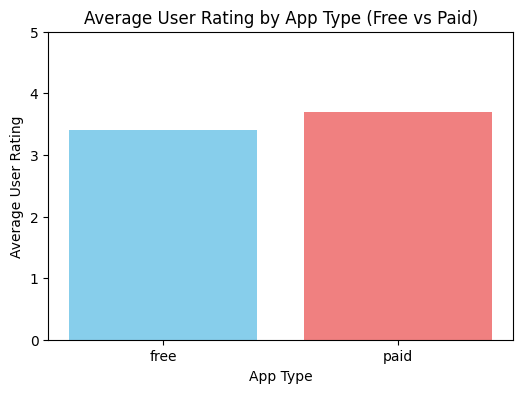

In [ ]:
import matplotlib.pyplot as plt

# Get avg user rating for paid vs free apps
df_price_rating = %sql SELECT CASE WHEN price > 0 THEN 'paid' ELSE 'free' END AS app_type, ROUND(AVG(user_rating), 1) AS avg_rating FROM AppleStore GROUP BY app_type;
# Convert SQL result to pandas DataFrame
df_price_rating = df_price_rating.DataFrame()

# Create a bar plot
plt.figure(figsize=(6, 4))
plt.bar(df_price_rating['app_type'], df_price_rating['avg_rating'], color=['skyblue', 'lightcoral'])
plt.xlabel('App Type')
plt.ylabel('Average User Rating')
plt.title('Average User Rating by App Type (Free vs Paid)')
plt.ylim(0, 5) # Set y-axis limit to 0-5 for rating scale
plt.show()

## The average user rating based on the number of supported languages



 * sqlite:///AppStore.db
Done.


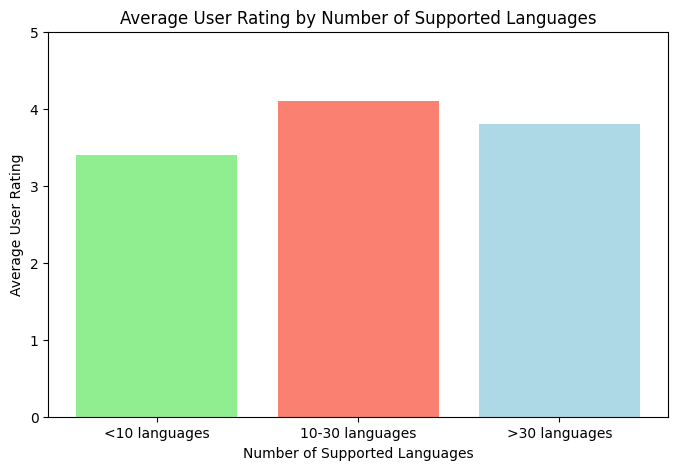

In [ ]:
# Get avg user rating based on the no. of supported languages
df_lang_rating = %sql SELECT CASE WHEN lang_num < 10 THEN '<10 languages' WHEN lang_num BETWEEN 10 AND 30 THEN '10-30 languages' ELSE '>30 languages' END AS language_bracket, round(avg(user_rating),1) AS avg_rating FROM AppleStore GROUP BY language_bracket ORDER BY CASE  language_bracket WHEN '<10 languages' THEN 1 WHEN '10-30 languages' THEN 2 WHEN '>30 languages' THEN 3 END ;
# Convert SQL result to pandas DataFrame
df_lang_rating = df_lang_rating.DataFrame()
# Create a bar plot
plt.figure(figsize=(8, 5))
plt.bar(df_lang_rating['language_bracket'], df_lang_rating['avg_rating'], color=['lightgreen', 'salmon', 'lightblue'])
plt.xlabel('Number of Supported Languages')
plt.ylabel('Average User Rating')
plt.title('Average User Rating by Number of Supported Languages')
plt.ylim(0, 5) # Set y-axis limit to 0-5 for rating scale
plt.show()

##Genres with the lowest average user ratings



 * sqlite:///AppStore.db
Done.


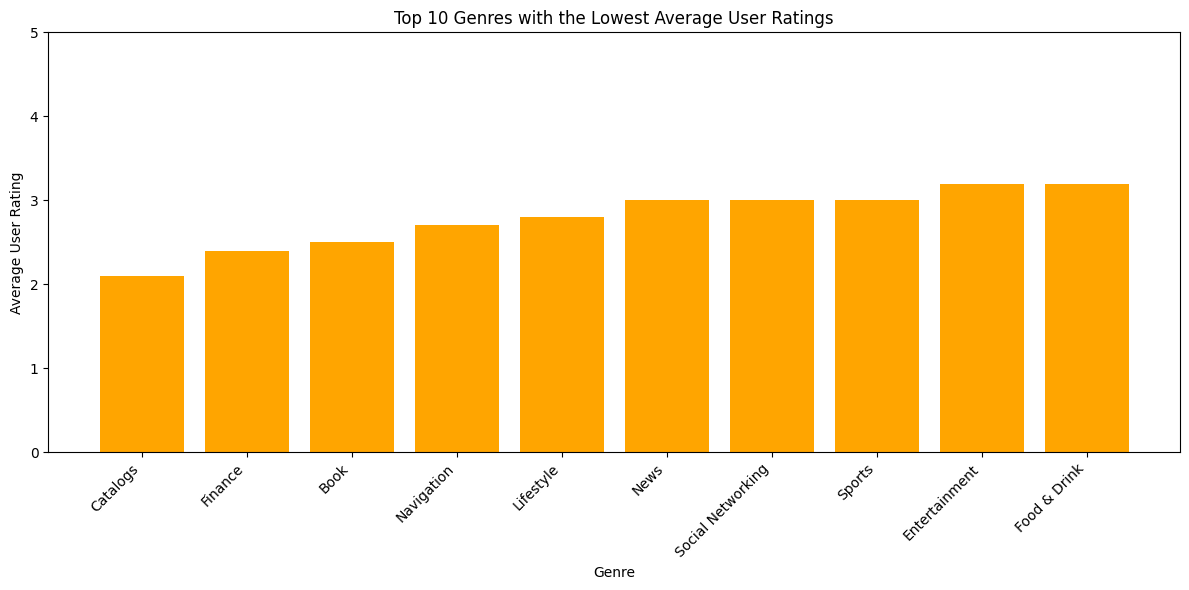

In [ ]:
# Get top 10 genres with the lowest avg user ratings
df_lowest_rated_genres = %sql SELECT prime_genre, round(AVG(user_rating),1) AS avg_rating FROM AppleStore GROUP BY prime_genre ORDER BY avg_rating ASC LIMIT 10;
# Convert SQL result to pandas DataFrame
df_lowest_rated_genres = df_lowest_rated_genres.DataFrame()

# Create a bar plot
plt.figure(figsize=(12, 6))
plt.bar(df_lowest_rated_genres['prime_genre'], df_lowest_rated_genres['avg_rating'], color='orange')
plt.xlabel('Genre')
plt.ylabel('Average User Rating')
plt.title('Top 10 Genres with the Lowest Average User Ratings')
plt.ylim(0, 5) # Set y-axis limit to 0-5 for rating scale
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

##The average user rating based on app description length



 * sqlite:///AppStore.db
Done.


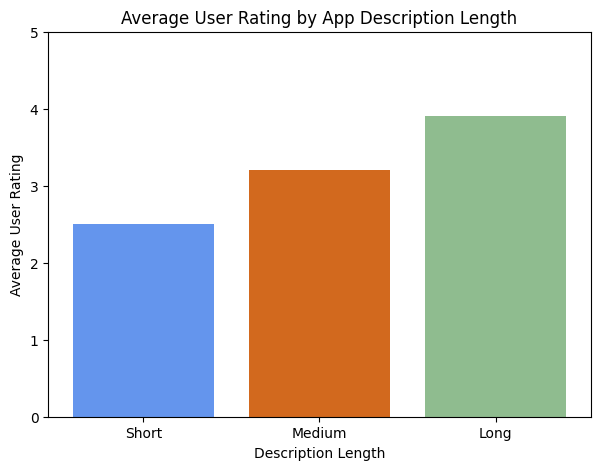

In [ ]:
# Get avg user rating based on app description length
df_desc_length_rating = %sql SELECT CASE WHEN length(b.app_desc) < 500 THEN 'Short' WHEN length(b.app_desc) BETWEEN 500 AND 1000 THEN 'Medium' ELSE 'Long' END AS description_length_bucket, ROUND(AVG(user_rating),1) AS avg_rating FROM AppleStore AS a JOIN appleStore_desc AS b ON a.id = b.id GROUP BY description_length_bucket ORDER BY avg_rating ASC;
# Convert SQL result to pandas DataFrame
df_desc_length_rating = df_desc_length_rating.DataFrame()

# Create a bar plot
plt.figure(figsize=(7, 5))
plt.bar(df_desc_length_rating['description_length_bucket'], df_desc_length_rating['avg_rating'], color=['cornflowerblue', 'chocolate', 'darkseagreen'])
plt.xlabel('Description Length')
plt.ylabel('Average User Rating')
plt.title('Average User Rating by App Description Length')
plt.ylim(0, 5) # Set y-axis limit to 0-5 for rating scale
plt.show()

##The average user rating based on app size


 * sqlite:///AppStore.db
Done.


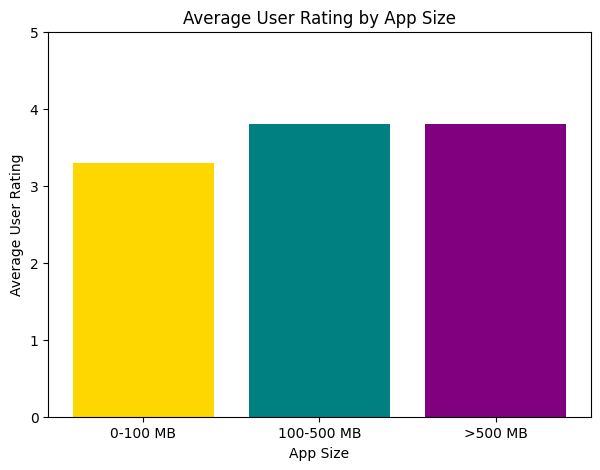

In [ ]:
# Get avg user rating based on app size
df_size_rating = %sql SELECT CASE WHEN size_bytes < 100000000 THEN '0-100 MB' WHEN size_bytes BETWEEN 100000000 AND 500000000 THEN '100-500 MB' ELSE '>500 MB' END AS size_bucket, ROUND(AVG(user_rating), 1) AS avg_rating FROM AppleStore GROUP BY size_bucket ORDER BY  CASE size_bucket WHEN '0-100 MB' THEN 1 WHEN '100-500 MB' THEN 2 WHEN '>500 MB' THEN 3 END;
# Convert SQL result to pandas DataFrame
df_size_rating = df_size_rating.DataFrame()
# Create a bar plot
plt.figure(figsize=(7, 5))
plt.bar(df_size_rating['size_bucket'], df_size_rating['avg_rating'], color=['gold', 'teal', 'purple'])
plt.xlabel('App Size')
plt.ylabel('Average User Rating')
plt.title('Average User Rating by App Size')
plt.ylim(0, 5) # Set y-axis limit to 0-5 for rating scale
plt.show()


## The average user rating based on content rating



 * sqlite:///AppStore.db
Done.


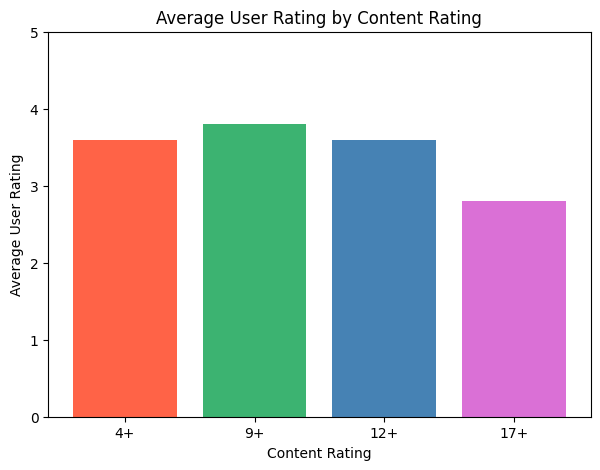

In [ ]:
# Get avg user rating based on content rating
df_cont_rating = %sql SELECT cont_rating, ROUND(AVG(user_rating), 1) AS avg_rating FROM AppleStore GROUP BY cont_rating ORDER BY CASE cont_rating WHEN '4+' THEN 1 WHEN '9+' THEN 2 WHEN '12+' THEN 3 ELSE 4 END;
# Convert SQL result to pandas DataFrame
df_cont_rating = df_cont_rating.DataFrame()

# Create a bar plot
plt.figure(figsize=(7, 5))
plt.bar(df_cont_rating['cont_rating'], df_cont_rating['avg_rating'], color=['tomato', 'mediumseagreen', 'steelblue', 'orchid'])
plt.xlabel('Content Rating')
plt.ylabel('Average User Rating')
plt.title('Average User Rating by Content Rating')
plt.ylim(0, 5) # Set y-axis limit to 0-5 for rating scale
plt.show()

In [ ]:
%reload_ext sql

## The average user rating based on the number of supported devices



 * sqlite:///AppStore.db
Done.


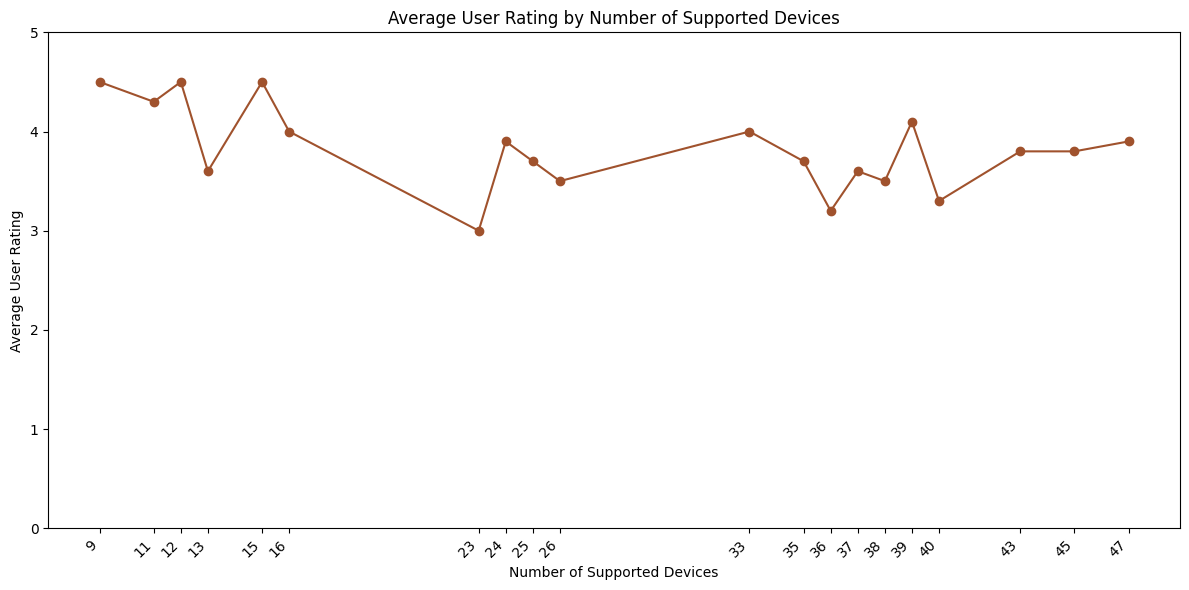

In [ ]:
# Get avg user rating based on the number of supported devices
df_sup_devices_rating = %sql SELECT sup_devices_num, ROUND(AVG(user_rating), 1) AS avg_rating FROM AppleStore GROUP BY sup_devices_num ORDER BY sup_devices_num ASC;
# Convert SQL result to pandas DataFrame
df_sup_devices_rating = df_sup_devices_rating.DataFrame()

# Create a line plot
plt.figure(figsize=(12, 6))
plt.plot(df_sup_devices_rating['sup_devices_num'], df_sup_devices_rating['avg_rating'], marker='o', linestyle='-', color='sienna')
plt.xlabel('Number of Supported Devices')
plt.ylabel('Average User Rating')
plt.title('Average User Rating by Number of Supported Devices')
plt.ylim(0, 5) # Set y-axis limit to 0-5 for rating scale
plt.xticks(df_sup_devices_rating['sup_devices_num'], rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

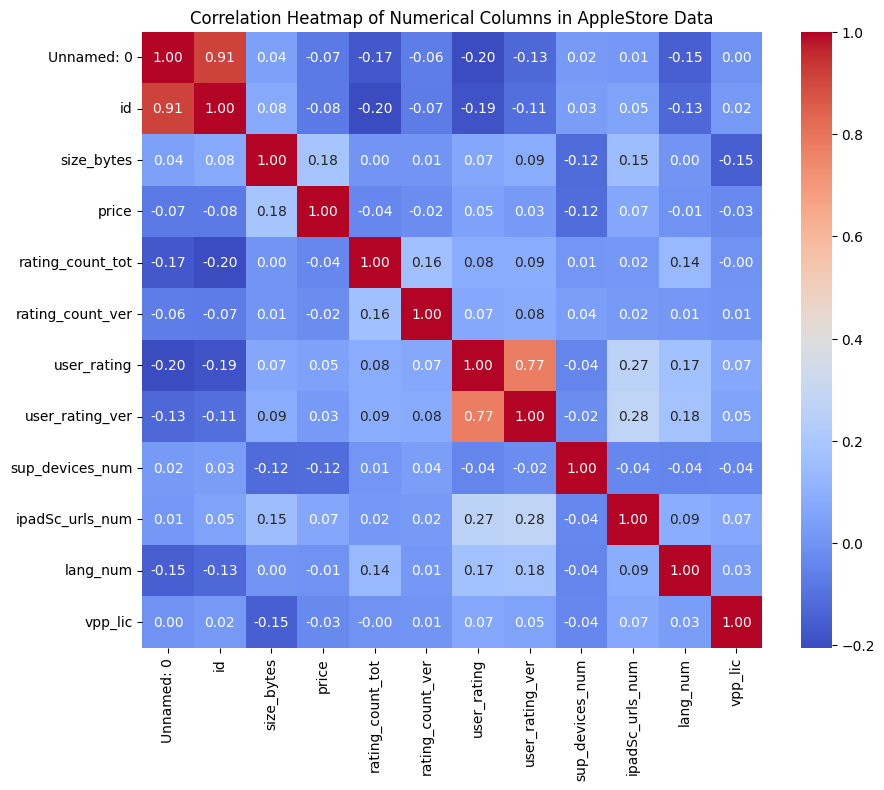

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns from the DataFrame
numerical_cols = df_store.select_dtypes(include=['int64', 'float64']).columns

# Calculate the correlation matrix
corr_matrix = df_store[numerical_cols].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Columns in AppleStore Data')
plt.show()

## The average user rating based on the number of iPad screenshots



 * sqlite:///AppStore.db
Done.


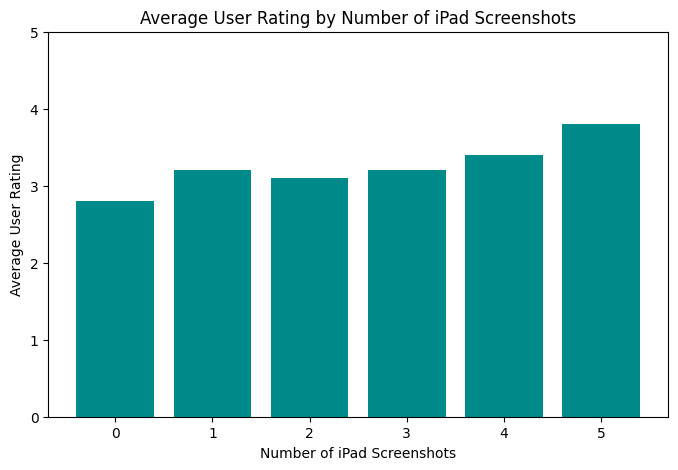

In [ ]:
# Get avg user rating based on the number of iPad screenshots
df_ipad_screenshots_rating = %sql SELECT ipadSc_urls_num, ROUND(AVG(user_rating), 1) AS avg_rating FROM AppleStore GROUP BY ipadSc_urls_num ORDER BY ipadSc_urls_num ASC;
# Convert SQL result to pandas DataFrame
df_ipad_screenshots_rating = df_ipad_screenshots_rating.DataFrame()

# Create a bar plot
plt.figure(figsize=(8, 5))
plt.bar(df_ipad_screenshots_rating['ipadSc_urls_num'].astype(str), df_ipad_screenshots_rating['avg_rating'], color='darkcyan')
plt.xlabel('Number of iPad Screenshots')
plt.ylabel('Average User Rating')
plt.title('Average User Rating by Number of iPad Screenshots')
plt.ylim(0, 5) # Set y-axis limit to 0-5 for rating scale
plt.show()

# **Summary**

## Data Analysis Key Findings

*   Paid apps have a slightly higher average rating (3.7) compared to free apps (3.4).
*   Apps supporting 10-30 languages have the highest average rating (4.1), followed by >30 languages (3.8), and <10 languages (3.4).
*   "Catalogs" (2.1), "Finance" (2.4), and "Book" (2.5) genres have the lowest average ratings.
*   Apps with long descriptions (>1000 characters) have the highest average rating (3.9).
*   Apps in the >500 MB and 100-500 MB size buckets have higher average ratings (3.8 for both) than apps in the 0-100 MB bucket (3.3).
*   '9+' rated apps have the highest average rating (3.8), followed by '4+' and '12+' (both 3.6), and '17+' (2.8).
*   Apps with 5 iPad screenshots have the highest average rating (3.8), followed by 4 (3.4).



# **Recommendations**


Based on our analysis, here are some recommendations for an app developer aiming to achieve higher ratings on the Apple Store:

1. **Prioritize localization**: Invest in 10–30 languages with quality translations.
2. **Write comprehensive app descriptions**: Provide detailed information about your app's features, functionality, and benefits to help users understand what to expect.
3. **Focus on optimizing for a moderate set of devices**: Instead of trying to support every single device, focus on optimizing your app for a key set of devices where you can ensure a smooth and high-quality user experience.
4. **Ensure high quality visuals**: Visuals are important for attracting users. Including a reasonable number of high-quality iPad screenshots can help users visualize the app and potentially lead to better ratings.
5. **Research low-rated genres carefully**: If you're developing in genres like "Catalogs," "Finance," or "Book," pay close attention to user feedback and competitor analysis to understand the specific challenges and areas for improvement in these categories.
6. **Continuously update and improve**: Regularly updating your app with bug fixes, performance enhancements, and new features based on user feedback is crucial for maintaining user satisfaction and improving ratings over time.

By considering these factors, developers can increase their chances of creating a successful and highly-rated app.

# **Sources**

Click here to [explore dataset](https://www.kaggle.com/code/avnishnish/analysis-of-apple-s-app-store)